<a href="https://colab.research.google.com/github/PaolinaCastany/Master_Thesis/blob/main/ThesisPart2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pickle
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the base folder path in Google Drive
# !!! IMPORTANT: Replace with the actual path to your base folder if it's different !!!
BASE_FOLDER = '/content/drive/MyDrive/Thesis_Music_Success'

# Define folder structure using the base folder
FOLDERS = {
    'data': os.path.join(BASE_FOLDER, 'data'),
    'plots': os.path.join(BASE_FOLDER, 'plots'),
    'models': os.path.join(BASE_FOLDER, 'models'),
    'results': os.path.join(BASE_FOLDER, 'results')
}

# Verify base folder exists (optional, but good practice)
if not os.path.exists(BASE_FOLDER):
    print(f"❌ Error: Base folder not found at {BASE_FOLDER}")
    print("Please check the BASE_FOLDER path and ensure Google Drive is mounted.")
else:
    # Save folder paths for later use in /content/
    FOLDERS_FILE_PATH = '/content/folders.pkl'
    with open(FOLDERS_FILE_PATH, 'wb') as f:
        pickle.dump(FOLDERS, f)
    print(f"✓ Folder paths saved to {FOLDERS_FILE_PATH}")
    print("Please ensure the paths within folders.pkl are correct and the corresponding directories exist in Google Drive.")

✓ Folder paths saved to /content/folders.pkl
Please ensure the paths within folders.pkl are correct and the corresponding directories exist in Google Drive.


GLOBAL MODELS TRAINING - ALL GENRES COMBINED
Author: Paolina CASTANY
Date: 2025-10-25 07:27
✓ Loaded folder paths from /content/folders.pkl

Verifying folder paths...
✓ Folder for 'data' found at /content/drive/MyDrive/Thesis_Music_Success/data
✓ Folder for 'plots' found at /content/drive/MyDrive/Thesis_Music_Success/plots
✓ Folder for 'models' found at /content/drive/MyDrive/Thesis_Music_Success/models
✓ Folder for 'results' found at /content/drive/MyDrive/Thesis_Music_Success/results

1. LOADING PREPROCESSED DATA

✓ Data loaded:
   Train: 133,496 tracks
   Test: 34,798 tracks
   Features: 13

2. DATA PREPARATION

📊 Data Overview:
   Training samples: 133,496
   Test samples: 34,798

   Regression target (popularity):
      Train - Mean: 18.41, Std: 14.80
      Test  - Mean: 29.72, Std: 15.13

   Classification target (is_hit):
      Train - Hit rate: 3.29%
      Test  - Hit rate: 9.28%

⚙️  Scaling features...
✓ Features scaled (mean≈0, std≈1)
✓ Saved model: scaler_global.pkl

3. REG

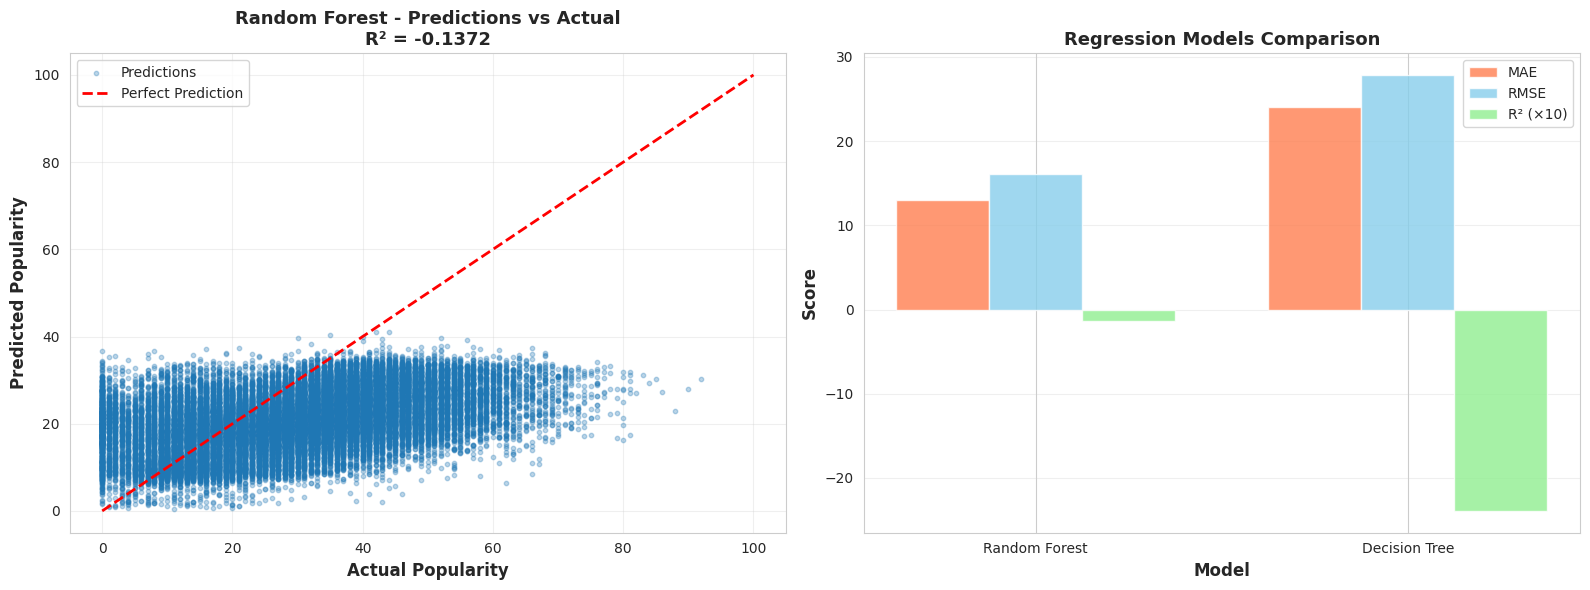

✓ Saved plot: 08_feature_importance_regression.png


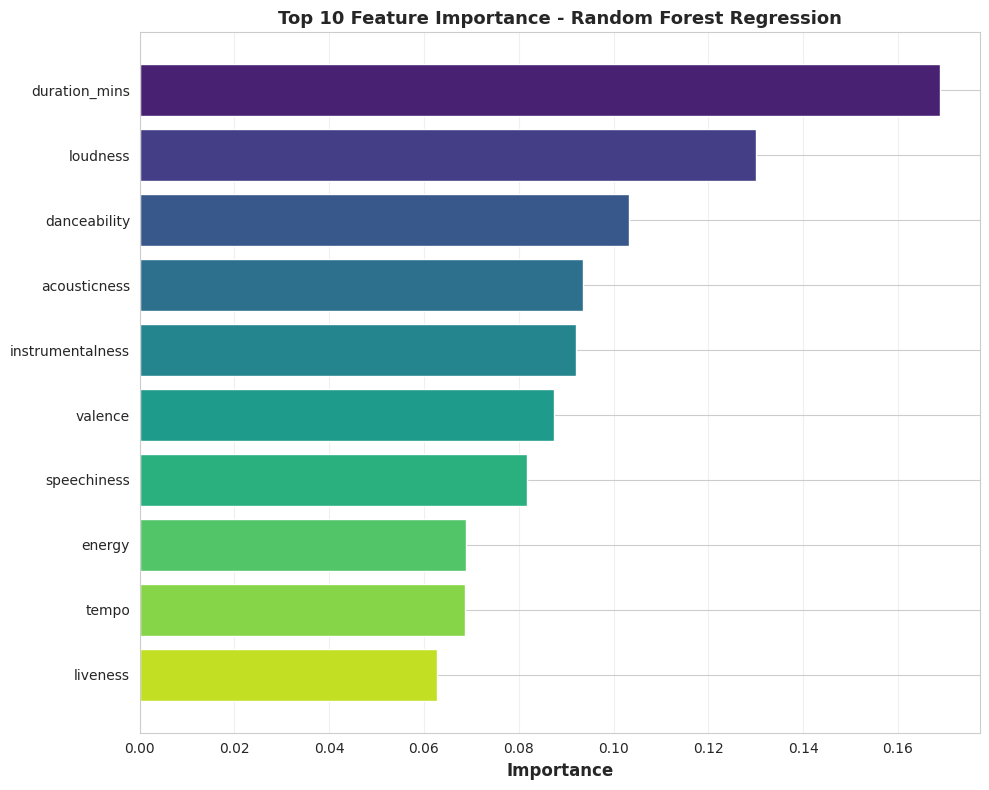


4. CLASSIFICATION MODELS - HIT PREDICTION

⚙️  Applying SMOTE for class balancing...
   Before SMOTE: 133,496 samples
      Class 0 (Non-hit): 129,104
      Class 1 (Hit):     4,392
   After SMOTE: 258,208 samples
      Class 0: 129,104
      Class 1: 129,104

------------------------------------------------------------
4.1 RANDOM FOREST CLASSIFIER
------------------------------------------------------------
Training model...

✓ Results:
   Accuracy:  0.7788
   Precision: 0.1829
   Recall:    0.3992
   F1-Score:  0.2509
   ROC-AUC:   0.7105

   Confusion Matrix:
      TN: 25,811 | FP:  5,758
      FN:  1,940 | TP:  1,289

   Top 5 Important Features:
      instrumentalness    : 0.1411
      duration_mins       : 0.1235
      loudness            : 0.1088
      acousticness        : 0.1032
      danceability        : 0.0979
✓ Saved model: rf_classification_global.pkl
✓ Saved: feature_importance_rf_classification.csv

------------------------------------------------------------
4.2 LOGIS

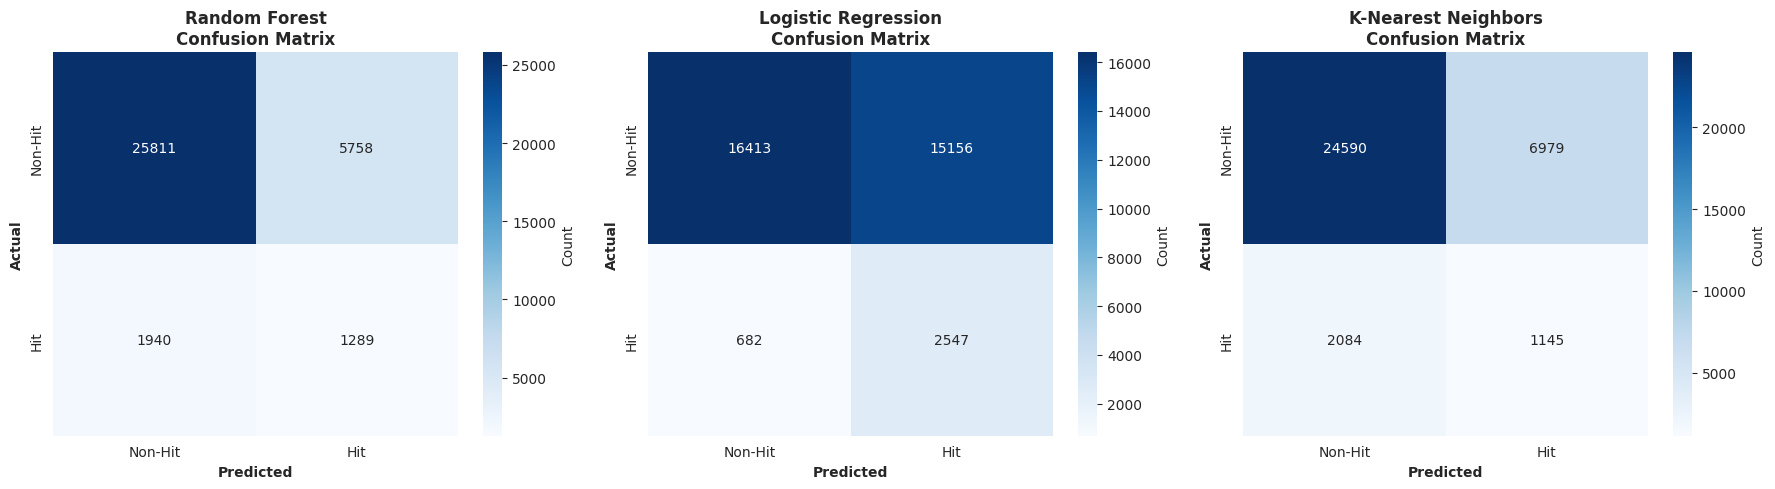

✓ Saved plot: 10_classification_metrics_comparison.png


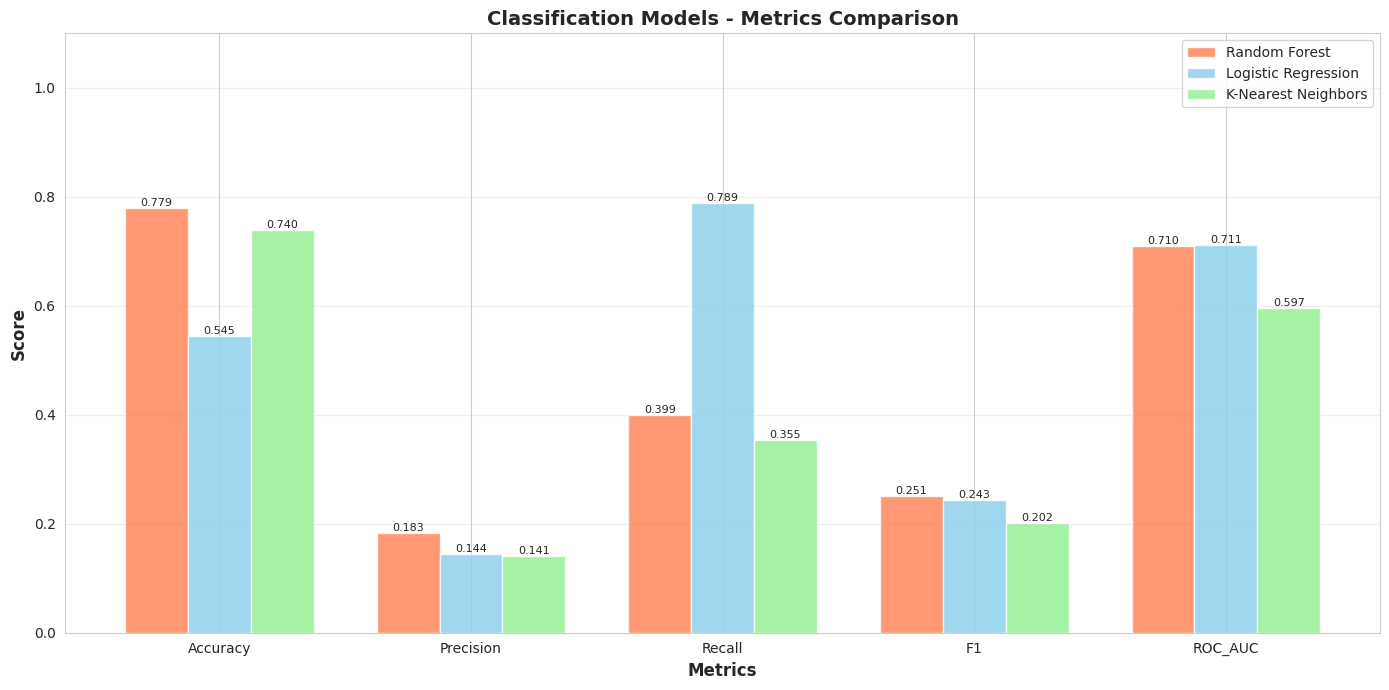

✓ Saved plot: 11_roc_curves.png


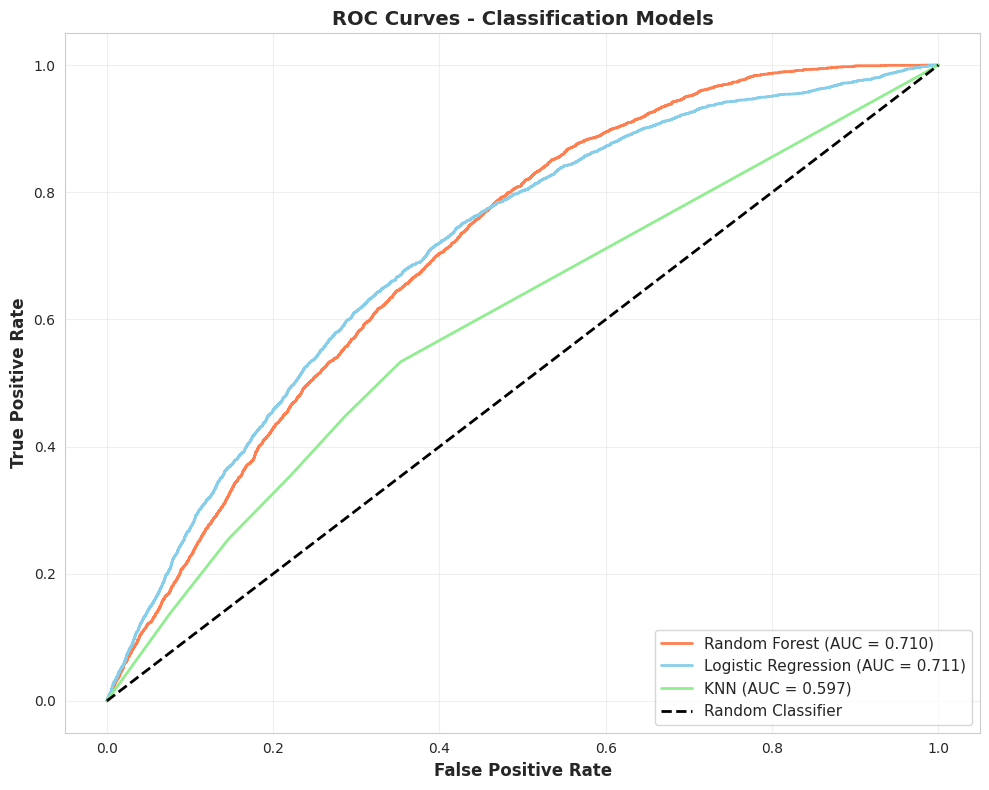

✓ Saved plot: 12_feature_importance_classification.png


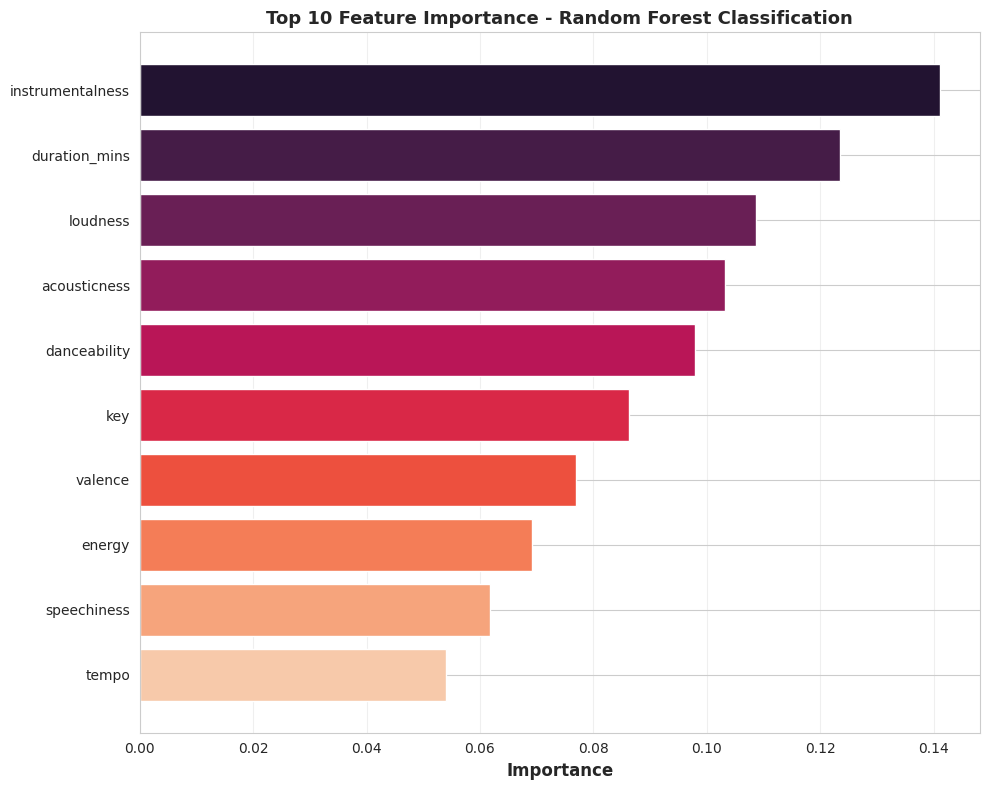


5. SUMMARY - GLOBAL MODELS PERFORMANCE

📊 REGRESSION (Popularity Prediction):
        Model       MAE      RMSE        R2
Random Forest 13.041939 16.135132 -0.137188
Decision Tree 24.039485 27.868767 -2.392523


📊 CLASSIFICATION (Hit Prediction):
              Model  Accuracy  Precision   Recall       F1  ROC_AUC
      Random Forest  0.778780   0.182915 0.399195 0.250876 0.710468
Logistic Regression  0.544859   0.143874 0.788789 0.243359 0.710924
K-Nearest Neighbors  0.739554   0.140940 0.354599 0.201709 0.596680


✅ GLOBAL MODELS TRAINING COMPLETE!

📁 Saved files:
   Models: 3 models
   Results: /content/drive/MyDrive/Thesis_Music_Success/results
   Plots: 6 visualizations

NEXT STEP: Run Notebook 3 - Genre-Specific Models


In [ ]:
"""
================================================================================
MASTER THESIS - MSc in Big Data & Business Analytics
Author: Paolina CASTANY

MUSIC SUCCESS PREDICTION: GENRE-SPECIFIC VS GLOBAL MODELS

NOTEBOOK 2: GLOBAL MODELS TRAINING
================================================================================
This notebook trains global models across all genres:
1. Regression models (popularity prediction)
2. Classification models (hit prediction)
3. Feature importance analysis
4. Comprehensive evaluation
================================================================================
"""

# ============================================================================
# SETUP
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                            accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            classification_report, roc_curve)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("GLOBAL MODELS TRAINING - ALL GENRES COMBINED")
print("="*80)
print(f"Author: Paolina CASTANY")
print(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}")
print("="*80)

# Define the path for the folders.pkl file
FOLDERS_FILE_PATH = '/content/folders.pkl'

# Load folder paths from the pickle file
try:
    with open(FOLDERS_FILE_PATH, 'rb') as f:
        FOLDERS = pickle.load(f)
    print(f"✓ Loaded folder paths from {FOLDERS_FILE_PATH}")
    # Verify that the loaded paths exist (assuming Google Drive is mounted)
    print("\nVerifying folder paths...")
    for folder_name, folder_path in FOLDERS.items():
        if not os.path.exists(folder_path):
            print(f"❌ Warning: Folder for '{folder_name}' not found at {folder_path}. Ensure Google Drive is mounted and the paths in folders.pkl are correct.")
        else:
            print(f"✓ Folder for '{folder_name}' found at {folder_path}")

except FileNotFoundError:
    print(f"❌ Error: {FOLDERS_FILE_PATH} not found.")
    print("Please ensure you have run the notebook that creates this file and saves it to /content/.")
    # Re-raise the error so the user knows the file is missing
    raise
except Exception as e:
    print(f"❌ An error occurred while loading {FOLDERS_FILE_PATH}: {e}")
    raise


DATA_FOLDER = FOLDERS['data']
PLOTS_FOLDER = FOLDERS['plots']
MODELS_FOLDER = FOLDERS['models']
RESULTS_FOLDER = FOLDERS['results']

def save_plot(filename):
    filepath = os.path.join(PLOTS_FOLDER, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"✓ Saved plot: {filename}")

def save_data(df, filename):
    filepath = os.path.join(RESULTS_FOLDER, filename)
    df.to_csv(filepath, index=False)
    print(f"✓ Saved: {filename}")

def save_model(model, filename):
    filepath = os.path.join(MODELS_FOLDER, filename)
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"✓ Saved model: {filename}")

# ============================================================================
# 1. LOAD DATA
# ============================================================================
print("\n" + "="*80)
print("1. LOADING PREPROCESSED DATA")
print("="*80)

# Check if data files exist before loading
train_data_path = os.path.join(DATA_FOLDER, 'spotify_train.csv')
test_data_path = os.path.join(DATA_FOLDER, 'spotify_test.csv')
feature_names_path = os.path.join(DATA_FOLDER, 'feature_names.csv')

if not os.path.exists(train_data_path):
    print(f"❌ Error: Training data not found at {train_data_path}")
    # Add logic to handle missing data, e.g., exit or prompt user
    raise FileNotFoundError(f"Training data not found at {train_data_path}")

if not os.path.exists(test_data_path):
    print(f"❌ Error: Test data not found at {test_data_path}")
    raise FileNotFoundError(f"Test data not found at {test_data_path}")

if not os.path.exists(feature_names_path):
    print(f"❌ Error: Feature names file not found at {feature_names_path}")
    raise FileNotFoundError(f"Feature names file not found at {feature_names_path}")


df_train = pd.read_csv(train_data_path)
df_test = pd.read_csv(test_data_path)
feature_names = pd.read_csv(feature_names_path)['feature'].tolist()

print(f"\n✓ Data loaded:")
print(f"   Train: {len(df_train):,} tracks")
print(f"   Test: {len(df_test):,} tracks")
print(f"   Features: {len(feature_names)}")

# ============================================================================
# 2. PREPARE DATA
# ============================================================================
print("\n" + "="*80)
print("2. DATA PREPARATION")
print("="*80)

X_train = df_train[feature_names]
X_test = df_test[feature_names]
y_train_reg = df_train['popularity']
y_test_reg = df_test['popularity']
y_train_clf = df_train['is_hit']
y_test_clf = df_test['is_hit']

print(f"\n📊 Data Overview:")
print(f"   Training samples: {len(X_train):,}")
print(f"   Test samples: {len(X_test):,}")
print(f"\n   Regression target (popularity):")
print(f"      Train - Mean: {y_train_reg.mean():.2f}, Std: {y_train_reg.std():.2f}")
print(f"      Test  - Mean: {y_test_reg.mean():.2f}, Std: {y_test_reg.std():.2f}")
print(f"\n   Classification target (is_hit):")
print(f"      Train - Hit rate: {y_train_clf.mean()*100:.2f}%")
print(f"      Test  - Hit rate: {y_test_clf.mean()*100:.2f}%")

# Scale features
print(f"\n⚙️  Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"✓ Features scaled (mean≈0, std≈1)")

save_model(scaler, 'scaler_global.pkl')

# ============================================================================
# 3. REGRESSION MODELS
# ============================================================================
print("\n" + "="*80)
print("3. REGRESSION MODELS - POPULARITY PREDICTION")
print("="*80)

regression_results = []

# ========== 3.1 Random Forest Regressor ==========
print("\n" + "-"*60)
print("3.1 RANDOM FOREST REGRESSOR")
print("-"*60)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

print("Training model...")
rf_reg.fit(X_train_scaled, y_train_reg)

y_pred_rf = rf_reg.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
r2_rf = r2_score(y_test_reg, y_pred_rf)

print(f"\n✓ Results:")
print(f"   MAE:  {mae_rf:.4f}")
print(f"   RMSE: {rmse_rf:.4f}")
print(f"   R²:   {r2_rf:.4f}")

# Feature importance
importance_rf = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n   Top 5 Important Features:")
for idx, row in importance_rf.head(5).iterrows():
    print(f"      {row['feature']:20s}: {row['importance']:.4f}")

regression_results.append({
    'Model': 'Random Forest',
    'MAE': mae_rf,
    'RMSE': rmse_rf,
    'R2': r2_rf
})

save_model(rf_reg, 'rf_regression_global.pkl')
save_data(importance_rf, 'feature_importance_rf_regression.csv')

# ========== 3.2 Baseline: Decision Tree ==========
print("\n" + "-"*60)
print("3.2 DECISION TREE REGRESSOR (Baseline)")
print("-"*60)

dt_reg = DecisionTreeClassifier(max_depth=10, random_state=42)
print("Training model...")
dt_reg.fit(X_train_scaled, y_train_reg)

y_pred_dt = dt_reg.predict(X_test_scaled)

mae_dt = mean_absolute_error(y_test_reg, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test_reg, y_pred_dt))
r2_dt = r2_score(y_test_reg, y_pred_dt)

print(f"\n✓ Results:")
print(f"   MAE:  {mae_dt:.4f}")
print(f"   RMSE: {rmse_dt:.4f}")
print(f"   R²:   {r2_dt:.4f}")

regression_results.append({
    'Model': 'Decision Tree',
    'MAE': mae_dt,
    'RMSE': rmse_dt,
    'R2': r2_dt
})

# Save regression results
regression_results_df = pd.DataFrame(regression_results)
save_data(regression_results_df, 'global_regression_results.csv')

# VISUALIZATION 1: Regression Results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predictions vs Actual
axes[0].scatter(y_test_reg, y_pred_rf, alpha=0.3, s=10, label='Predictions')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Popularity', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Predicted Popularity', fontweight='bold', fontsize=12)
axes[0].set_title(f'Random Forest - Predictions vs Actual\nR² = {r2_rf:.4f}',
                  fontweight='bold', fontsize=13)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Model Comparison
models = regression_results_df['Model'].values
x_pos = np.arange(len(models))
width = 0.25

axes[1].bar(x_pos - width, regression_results_df['MAE'], width,
            label='MAE', alpha=0.8, color='coral')
axes[1].bar(x_pos, regression_results_df['RMSE'], width,
            label='RMSE', alpha=0.8, color='skyblue')
axes[1].bar(x_pos + width, regression_results_df['R2']*10, width,
            label='R² (×10)', alpha=0.8, color='lightgreen')

axes[1].set_xlabel('Model', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Score', fontweight='bold', fontsize=12)
axes[1].set_title('Regression Models Comparison', fontweight='bold', fontsize=13)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_plot('07_global_regression_results.png')
plt.show()

# VISUALIZATION 2: Feature Importance (Regression)
plt.figure(figsize=(10, 8))
top_features = importance_rf.head(10)
plt.barh(range(len(top_features)), top_features['importance'],
         color=sns.color_palette("viridis", len(top_features)))
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance', fontweight='bold', fontsize=12)
plt.title('Top 10 Feature Importance - Random Forest Regression',
          fontweight='bold', fontsize=13)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_plot('08_feature_importance_regression.png')
plt.show()

# ============================================================================
# 4. CLASSIFICATION MODELS
# ============================================================================
print("\n" + "="*80)
print("4. CLASSIFICATION MODELS - HIT PREDICTION")
print("="*80)

classification_results = []

# Apply SMOTE
print(f"\n⚙️  Applying SMOTE for class balancing...")
print(f"   Before SMOTE: {len(y_train_clf):,} samples")
print(f"      Class 0 (Non-hit): {(y_train_clf==0).sum():,}")
print(f"      Class 1 (Hit):     {(y_train_clf==1).sum():,}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_clf)

print(f"   After SMOTE: {len(y_train_smote):,} samples")
print(f"      Class 0: {(y_train_smote==0).sum():,}")
print(f"      Class 1: {(y_train_smote==1).sum():,}")

# ========== 4.1 Random Forest Classifier ==========
print("\n" + "-"*60)
print("4.1 RANDOM FOREST CLASSIFIER")
print("-"*60)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training model...")
rf_clf.fit(X_train_smote, y_train_smote)

y_pred_rf_clf = rf_clf.predict(X_test_scaled)
y_prob_rf_clf = rf_clf.predict_proba(X_test_scaled)[:, 1]

# Evaluation
acc_rf = accuracy_score(y_test_clf, y_pred_rf_clf)
prec_rf = precision_score(y_test_clf, y_pred_rf_clf, zero_division=0)
rec_rf = recall_score(y_test_clf, y_pred_rf_clf, zero_division=0)
f1_rf = f1_score(y_test_clf, y_pred_rf_clf, zero_division=0)
roc_auc_rf = roc_auc_score(y_test_clf, y_prob_rf_clf)

print(f"\n✓ Results:")
print(f"   Accuracy:  {acc_rf:.4f}")
print(f"   Precision: {prec_rf:.4f}")
print(f"   Recall:    {rec_rf:.4f}")
print(f"   F1-Score:  {f1_rf:.4f}")
print(f"   ROC-AUC:   {roc_auc_rf:.4f}")

cm_rf = confusion_matrix(y_test_clf, y_pred_rf_clf)
print(f"\n   Confusion Matrix:")
print(f"      TN: {cm_rf[0,0]:6,} | FP: {cm_rf[0,1]:6,}")
print(f"      FN: {cm_rf[1,0]:6,} | TP: {cm_rf[1,1]:6,}")

# Feature importance
importance_rf_clf = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n   Top 5 Important Features:")
for idx, row in importance_rf_clf.head(5).iterrows():
    print(f"      {row['feature']:20s}: {row['importance']:.4f}")

classification_results.append({
    'Model': 'Random Forest',
    'Accuracy': acc_rf,
    'Precision': prec_rf,
    'Recall': rec_rf,
    'F1': f1_rf,
    'ROC_AUC': roc_auc_rf
})

save_model(rf_clf, 'rf_classification_global.pkl')
save_data(importance_rf_clf, 'feature_importance_rf_classification.csv')

# ========== 4.2 Logistic Regression ==========
print("\n" + "-"*60)
print("4.2 LOGISTIC REGRESSION")
print("-"*60)

log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
print("Training model...")
log_reg.fit(X_train_smote, y_train_smote)

y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

acc_log = accuracy_score(y_test_clf, y_pred_log)
prec_log = precision_score(y_test_clf, y_pred_log, zero_division=0)
rec_log = recall_score(y_test_clf, y_pred_log, zero_division=0)
f1_log = f1_score(y_test_clf, y_pred_log, zero_division=0)
roc_auc_log = roc_auc_score(y_test_clf, y_prob_log)

print(f"\n✓ Results:")
print(f"   Accuracy:  {acc_log:.4f}")
print(f"   Precision: {prec_log:.4f}")
print(f"   Recall:    {rec_log:.4f}")
print(f"   F1-Score:  {f1_log:.4f}")
print(f"   ROC-AUC:   {roc_auc_log:.4f}")

classification_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': acc_log,
    'Precision': prec_log,
    'Recall': rec_log,
    'F1': f1_log,
    'ROC_AUC': roc_auc_log
})

# ========== 4.3 K-Nearest Neighbors ==========
print("\n" + "-"*60)
print("4.3 K-NEAREST NEIGHBORS")
print("-"*60)

knn_clf = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
print("Training model...")
knn_clf.fit(X_train_smote, y_train_smote)

y_pred_knn = knn_clf.predict(X_test_scaled)
y_prob_knn = knn_clf.predict_proba(X_test_scaled)[:, 1]

acc_knn = accuracy_score(y_test_clf, y_pred_knn)
prec_knn = precision_score(y_test_clf, y_pred_knn, zero_division=0)
rec_knn = recall_score(y_test_clf, y_pred_knn, zero_division=0)
f1_knn = f1_score(y_test_clf, y_pred_knn, zero_division=0)
roc_auc_knn = roc_auc_score(y_test_clf, y_prob_knn)

print(f"\n✓ Results:")
print(f"   Accuracy:  {acc_knn:.4f}")
print(f"   Precision: {prec_knn:.4f}")
print(f"   Recall:    {rec_knn:.4f}")
print(f"   F1-Score:  {f1_knn:.4f}")
print(f"   ROC-AUC:   {roc_auc_knn:.4f}")

classification_results.append({
    'Model': 'K-Nearest Neighbors',
    'Accuracy': acc_knn,
    'Precision': prec_knn,
    'Recall': rec_knn,
    'F1': f1_knn,
    'ROC_AUC': roc_auc_knn
})

# Save classification results
classification_results_df = pd.DataFrame(classification_results)
save_data(classification_results_df, 'global_classification_results.csv')

# VISUALIZATION 3: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cms = [cm_rf, confusion_matrix(y_test_clf, y_pred_log), confusion_matrix(y_test_clf, y_pred_knn)]
titles = ['Random Forest', 'Logistic Regression', 'K-Nearest Neighbors']

for idx, (cm, title) in enumerate(zip(cms, titles)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-Hit', 'Hit'],
                yticklabels=['Non-Hit', 'Hit'],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{title}\nConfusion Matrix', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Actual', fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontweight='bold')

plt.tight_layout()
save_plot('09_confusion_matrices.png')
plt.show()

# VISUALIZATION 4: Classification Metrics Comparison
fig, ax = plt.subplots(figsize=(14, 7))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
x = np.arange(len(metrics_names))
width = 0.25

models = classification_results_df['Model'].values
colors = ['coral', 'skyblue', 'lightgreen']

for i, (model, color) in enumerate(zip(models, colors)):
    values = classification_results_df[classification_results_df['Model'] == model][metrics_names].values[0]
    bars = ax.bar(x + i*width, values, width, label=model, alpha=0.8, color=color)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metrics', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Classification Models - Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

plt.tight_layout()
save_plot('10_classification_metrics_comparison.png')
plt.show()

# VISUALIZATION 5: ROC Curves
plt.figure(figsize=(10, 8))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test_clf, y_prob_rf_clf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})',
         linewidth=2, color='coral')

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test_clf, y_prob_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.3f})',
         linewidth=2, color='skyblue')

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test_clf, y_prob_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.3f})',
         linewidth=2, color='lightgreen')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
plt.title('ROC Curves - Classification Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
save_plot('11_roc_curves.png')
plt.show()

# VISUALIZATION 6: Feature Importance (Classification)
plt.figure(figsize=(10, 8))
top_features_clf = importance_rf_clf.head(10)
plt.barh(range(len(top_features_clf)), top_features_clf['importance'],
         color=sns.color_palette("rocket", len(top_features_clf)))
plt.yticks(range(len(top_features_clf)), top_features_clf['feature'])
plt.xlabel('Importance', fontweight='bold', fontsize=12)
plt.title('Top 10 Feature Importance - Random Forest Classification',
          fontweight='bold', fontsize=13)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_plot('12_feature_importance_classification.png')
plt.show()

# ============================================================================
# 5. SUMMARY
# ============================================================================
print("\n" + "="*80)
print("5. SUMMARY - GLOBAL MODELS PERFORMANCE")
print("="*80)

print("\n📊 REGRESSION (Popularity Prediction):")
print(regression_results_df.to_string(index=False))

print("\n\n📊 CLASSIFICATION (Hit Prediction):")
print(classification_results_df.to_string(index=False))

print("\n\n✅ GLOBAL MODELS TRAINING COMPLETE!")
print(f"\n📁 Saved files:")
print(f"   Models: {len([f for f in os.listdir(MODELS_FOLDER) if 'global' in f])} models")
print(f"   Results: {RESULTS_FOLDER}")
print(f"   Plots: 6 visualizations")

print("\n" + "="*80)
print("NEXT STEP: Run Notebook 3 - Genre-Specific Models")
print("="*80)